In [ ]:
!git clone https://github.com/d4-5/NLP4.git
%cd NLP4

In [ ]:
!pip install -r requirements.txt

In [ ]:
%cd NLP4

In [2]:
from pathlib import Path
import pandas as pd

root = Path('..').resolve()
DATA_DIR = root / 'data'
processed_path = DATA_DIR / 'processed_v2.csv'
labels_path = DATA_DIR / 'labels.csv'

print('processed exists:', processed_path.exists())
print('labels exists:', labels_path.exists())

processed_df = pd.read_csv(processed_path)
labels_df = pd.read_csv(labels_path)

processed_df.head(3)


processed exists: True
labels exists: True


,text_id,text_clean,sentences
0,text_0,"Дорогою зупинялися в селах, старцювали. Устимк...","['Дорогою зупинялися в селах, старцювали.', 'У..."
1,text_1,"То молитви продавав свої спудейські, то щось к...","['То молитви продавав свої спудейські, то щось..."
2,text_2,"Дуже часто дід досить точно вказував, куди сам...","['Дуже часто дід досить точно вказував, куди с..."


In [3]:
import sys
from datetime import datetime, timezone

sys.path.append(str(root))
from src.split import make_splits, save_splits

seed = 42
ratios = (0.8, 0.1, 0.1)

label_counts = labels_df.groupby(['text_id','label']).size().reset_index(name='count')
idx = label_counts.groupby('text_id')['count'].idxmax()
dominant = label_counts.loc[idx][['text_id','label']].rename(columns={'label':'dominant_label'})

merged = processed_df[['text_id']].merge(dominant, on='text_id', how='left')
merged['dominant_label'] = merged['dominant_label'].fillna('NO_ENTITY')

splits = make_splits(
    merged,
    seed=seed,
    id_col='text_id',
    stratify_col='dominant_label',
    ratios=ratios,
)

{key: len(val) for key, val in splits.items()}

{'train': 8929, 'val': 1116, 'test': 1116}

In [4]:
from pathlib import Path
import json

save_splits(splits, DATA_DIR / 'sample')

manifest = {
    'seed': seed,
    'strategy': "stratified",
    'ratios': {'train': ratios[0], 'val': ratios[1], 'test': ratios[2]},
    'sizes': {k: len(v) for k, v in splits.items()},
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'columns': {
        'id_col': 'text_id',
        'stratify_col': 'dominant_label',
        'group_col': None,
        'time_col': None,
    },
}

Path('docs').mkdir(parents=True, exist_ok=True)
with open('docs/splits_manifest_lab5.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

manifest

{'seed': 42,
 'strategy': 'stratified',
 'ratios': {'train': 0.8, 'val': 0.1, 'test': 0.1},
 'sizes': {'train': 8929, 'val': 1116, 'test': 1116},
 'generated_at': '2026-03-16T15:46:08.357452+00:00',
 'columns': {'id_col': 'text_id',
  'stratify_col': 'dominant_label',
  'group_col': None,
  'time_col': None}}

In [5]:
import pandas as pd

label_tables = {}
for split, ids in splits.items():
    subset = labels_df[labels_df['text_id'].isin(ids)]
    counts = subset['label'].value_counts().sort_index()
    label_tables[split] = counts

labels_table = pd.DataFrame(label_tables).fillna(0).astype(int)
labels_table

,train,val,test
label,,,
ART,325,39,34
DATE,962,114,130
DOC,78,10,13
JOB,1035,132,153
LOC,1696,180,285
MISC,280,41,50
MON,503,63,52
ORG,2915,351,376
PCT,131,19,21


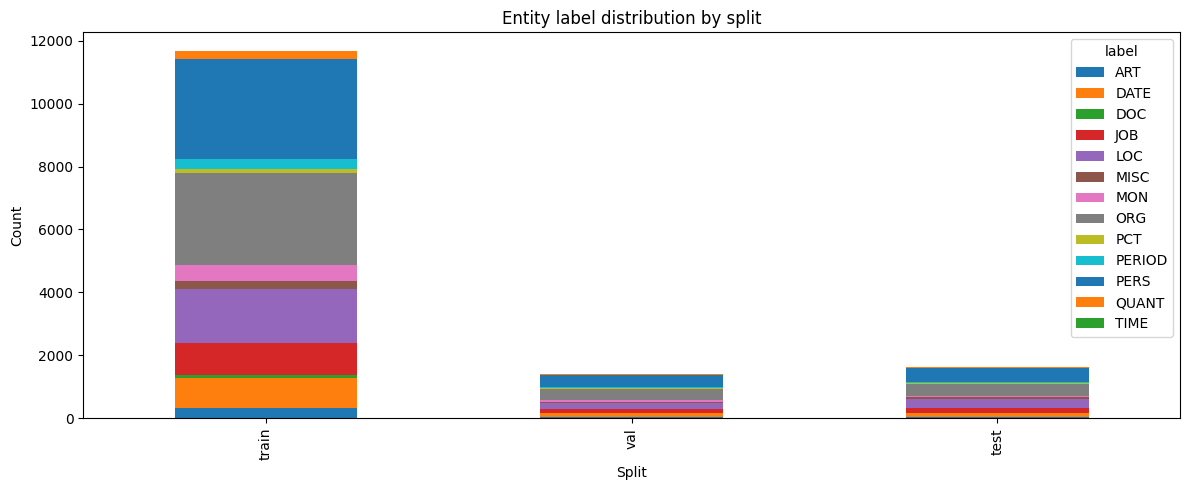

In [6]:
import matplotlib.pyplot as plt

labels_table.T.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Entity label distribution by split')
plt.ylabel('Count')
plt.xlabel('Split')
plt.tight_layout()
plt.show()

In [7]:
length_stats = {}
for split, ids in splits.items():
    texts = processed_df[processed_df['text_id'].isin(ids)]['text_clean'].fillna('')
    lengths = texts.str.len()
    length_stats[split] = {
        'count': len(lengths),
        'mean': float(lengths.mean()),
        'median': float(lengths.median()),
        'p05': float(lengths.quantile(0.05)),
        'p95': float(lengths.quantile(0.95)),
    }

length_stats

{'train': {'count': 8929,
  'mean': 112.69615858438794,
  'median': 87.0,
  'p05': 16.0,
  'p95': 298.0},
 'val': {'count': 1116,
  'mean': 111.61379928315412,
  'median': 87.0,
  'p05': 16.0,
  'p95': 293.0},
 'test': {'count': 1116,
  'mean': 118.80913978494624,
  'median': 90.0,
  'p05': 19.0,
  'p95': 318.25}}

In [8]:
text_by_id = processed_df.set_index('text_id')['text_clean'].fillna('')
texts_split = {k: text_by_id.loc[v].astype(str) for k, v in splits.items()}

set_train = set(texts_split['train'])
set_val = set(texts_split['val'])
set_test = set(texts_split['test'])

exact_dup = {
    'train_val': len(set_train & set_val),
    'train_test': len(set_train & set_test),
    'val_test': len(set_val & set_test),
}

exact_dup

{'train_val': 11, 'train_test': 5, 'val_test': 4}

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

threshold = 0.95

vectorizer = TfidfVectorizer(min_df=2, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(texts_split['train'].tolist())
X_val = vectorizer.transform(texts_split['val'].tolist())
X_test = vectorizer.transform(texts_split['test'].tolist())

train_ids = splits['train']
val_ids = splits['val']
test_ids = splits['test']


def near_dup_pairs(X_ref, X_query, ref_ids, query_ids, chunk_size=256, max_examples=5):
    total_pairs = 0
    examples = []
    for start in range(0, X_query.shape[0], chunk_size):
        end = min(start + chunk_size, X_query.shape[0])
        chunk = X_query[start:end]
        sims = cosine_similarity(chunk, X_ref, dense_output=False).tocsr()
        for i in range(sims.shape[0]):
            row = sims.getrow(i)
            if row.nnz == 0:
                continue
            mask = row.data >= threshold
            if not mask.any():
                continue
            cols = row.indices[mask]
            total_pairs += len(cols)
            if len(examples) < max_examples:
                for col in cols:
                    examples.append((query_ids[start + i], ref_ids[col], float(row.data[list(row.indices).index(col)])))
                    if len(examples) >= max_examples:
                        break
    return total_pairs, examples

near_train_test, ex_train_test = near_dup_pairs(X_train, X_test, train_ids, test_ids)
near_train_val, ex_train_val = near_dup_pairs(X_train, X_val, train_ids, val_ids)

near_train_test, near_train_val, ex_train_test, ex_train_val

(91,
 256,
 [('text_10304', 'text_9449', 1.0000000000000002),
  ('text_10304', 'text_10292', 1.0000000000000002),
  ('text_10304', 'text_10631', 1.0000000000000002),
  ('text_10304', 'text_9909', 1.0000000000000002),
  ('text_10304', 'text_8695', 1.0000000000000002)],
 [('text_11045', 'text_9449', 1.0000000000000002),
  ('text_11045', 'text_10292', 1.0000000000000002),
  ('text_11045', 'text_10631', 1.0000000000000002),
  ('text_11045', 'text_9909', 1.0000000000000002),
  ('text_11045', 'text_8695', 1.0000000000000002)])

In [10]:
import re

patterns = [
    r"\bCategory\s*:",
    r"\blabel\s*=" ,
    r"\bclass\s*=" ,
    r"\btopic\s*=" ,
    r"\bPER\b", r"\bORG\b", r"\bLOC\b", r"\bDATE\b", r"\bMONEY\b",
]
regex = re.compile("|".join(patterns), flags=re.IGNORECASE)

bad_rows = processed_df[processed_df['text_clean'].fillna('').str.contains(regex)]

len(bad_rows), bad_rows['text_id'].head(10).tolist()

(0, [])

In [12]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
])

X_train_tfidf = pipe.fit_transform(texts_split['train'].tolist())
X_val_tfidf = pipe.transform(texts_split['val'].tolist())
X_test_tfidf = pipe.transform(texts_split['test'].tolist())

X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape

((8929, 22346), (1116, 22346), (1116, 22346))